# Named Entity Recognition (NER) and POS Tagging with spaCy

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement NER using spaCy
- Perform POS tagging using spaCy
- Extract named entities from text
- Analyze and visualize NER results

## 🔗 Prerequisites

- ✅ Unit 2: Text representation completed
- ✅ Understanding of NLP fundamentals
- ✅ Python, spaCy knowledge

---

This notebook covers practical activities from **Course 07, Unit 3**:
- Implementing NER and POS tagging using spaCy

---

## Introduction

**Named Entity Recognition (NER)** identifies and classifies named entities (persons, organizations, locations, etc.) in text. **POS Tagging** assigns part-of-speech tags (noun, verb, adjective, etc.) to words.

## 📥 Inputs & 📤 Outputs

**Inputs:** two short sample texts defined in the code cells (a tech-companies paragraph for NER, one sentence for POS tagging) and spaCy's small English model `en_core_web_sm`.

**Outputs:** the extracted entities with their types (12 in this run), a token-by-token POS table, and a bar chart of entity-type counts — all computed live by spaCy.

---

In [1]:
# Setup: import the analysis stack and load spaCy's small English pipeline.
# The try/except guards let the notebook explain itself (rather than crash)
# if spaCy or its downloaded model is missing on a student machine.

import numpy as np
import pandas as pd
from collections import Counter

# Try importing spaCy
try:
    import spacy
    HAS_SPACY = True
    try:
        nlp = spacy.load("en_core_web_sm")
        print("✅ spaCy English model loaded!")
    except OSError:
        print("⚠️  spaCy model not found. Download with: python -m spacy download en_core_web_sm")
        print("   Using basic spaCy without model...")
        nlp = None
except ImportError:
    HAS_SPACY = False
    nlp = None
    print("⚠️  spaCy not available. Install with: pip install spacy")

print("\n✅ Libraries imported!")

✅ spaCy English model loaded!

✅ Libraries imported!


## Part 1: Named Entity Recognition (NER) with spaCy


In [2]:
# Named Entity Recognition: let spaCy find the people, companies, places, and dates.
# NER turns free text into structured facts — the first step of information-
# extraction pipelines (news mining, resume parsing, knowledge graphs).

if HAS_SPACY and nlp is not None:
    # Sample text for NER
    text = """
    Apple Inc. is an American multinational technology company headquartered in 
    Cupertino, California. Tim Cook is the CEO of Apple. The company was founded 
    by Steve Jobs in 1976. Microsoft Corporation, founded by Bill Gates, is 
    another major technology company based in Redmond, Washington.
    """
    
    print("=" * 60)
    print("Named Entity Recognition (NER)")
    print("=" * 60)
    print(f"\nInput text:\n{text.strip()}\n")
    
    # Process text with spaCy
    doc = nlp(text)
    
    # Extract named entities
    print("Named Entities Found:")
    print("-" * 60)
    entities = []
    for ent in doc.ents:
        entities.append({
            'Text': ent.text, 'Label': ent.label_,
            'Description': spacy.explain(ent.label_)
        })
        print(f"{ent.text:20s} | {ent.label_:15s} | {spacy.explain(ent.label_)}")
    
    print(f"\nTotal entities found: {len(entities)}")
    
    # Count by entity type
    entity_counts = Counter([ent['Label'] for ent in entities])
    print("\nEntity type distribution:")
    for label, count in entity_counts.items():
        print(f"  {label}: {count}")
else:
    print("=" * 60)
    print("NER with spaCy (Installation Required)")
    print("=" * 60)
    print("""
    To use spaCy for NER:
    
    1. Install spaCy:
       pip install spacy
    
    2. Download English model:
       python -m spacy download en_core_web_sm
    
    3. Use spaCy:
       import spacy
       nlp = spacy.load("en_core_web_sm")
       doc = nlp(text)
       for ent in doc.ents:
           print(ent.text, ent.label_)
    """)

Named Entity Recognition (NER)

Input text:
Apple Inc. is an American multinational technology company headquartered in 
    Cupertino, California. Tim Cook is the CEO of Apple. The company was founded 
    by Steve Jobs in 1976. Microsoft Corporation, founded by Bill Gates, is 
    another major technology company based in Redmond, Washington.

Named Entities Found:
------------------------------------------------------------
Apple Inc.           | ORG             | Companies, agencies, institutions, etc.
American             | NORP            | Nationalities or religious or political groups
Cupertino            | GPE             | Countries, cities, states
California           | GPE             | Countries, cities, states
Tim Cook             | PERSON          | People, including fictional
Apple                | ORG             | Companies, agencies, institutions, etc.
Steve Jobs           | PERSON          | People, including fictional
1976                 | DATE            | Absolu

## Part 2: Part-of-Speech (POS) Tagging with spaCy


In [3]:
# Part-of-speech tagging: label every token with its grammatical role.
# POS tags feed downstream tools (lemmatizers, parsers, NER itself) and reveal
# HOW a sentence is built, not just which words it contains.

if HAS_SPACY and nlp is not None:
    # Sample sentence for POS tagging
    sentence = "Natural language processing helps computers understand human language."
    
    print("=" * 60)
    print("Part-of-Speech (POS) Tagging")
    print("=" * 60)
    print(f"\nInput sentence: {sentence}\n")
    
    # Process sentence
    doc = nlp(sentence)
    
    # Extract POS tags
    print("POS Tags:")
    print("-" * 60)
    pos_data = []
    for token in doc:
        pos_data.append({
            'Word': token.text, 'POS': token.pos_,
            'POS_Description': spacy.explain(token.pos_),
            'Tag': token.tag_,
            'Tag_Description': spacy.explain(token.tag_)
        })
        print(f"{token.text:15s} | {token.pos_:10s} | {token.tag_:10s} | {spacy.explain(token.pos_)}")
    
    # Count POS tags
    pos_counts = Counter([token.pos_ for token in doc])
    print("\nPOS distribution:")
    for pos, count in pos_counts.items():
        print(f"  {pos}: {count}")
else:
    print("Note: Install spaCy and download model for POS tagging")

Part-of-Speech (POS) Tagging

Input sentence: Natural language processing helps computers understand human language.

POS Tags:
------------------------------------------------------------
Natural         | ADJ        | JJ         | adjective
language        | NOUN       | NN         | noun
processing      | NOUN       | NN         | noun
helps           | VERB       | VBZ        | verb
computers       | NOUN       | NNS        | noun
understand      | VERB       | VB         | verb
human           | ADJ        | JJ         | adjective
language        | NOUN       | NN         | noun
.               | PUNCT      | .          | punctuation

POS distribution:
  ADJ: 2
  NOUN: 4
  VERB: 2
  PUNCT: 1


## Part 3: Analyzing and Visualizing the NER Results

A quick analysis pass over the entities extracted in Part 1: how many entities of each type did the model
find? Bar-charting the distribution is a standard first look at NER output on a new corpus.


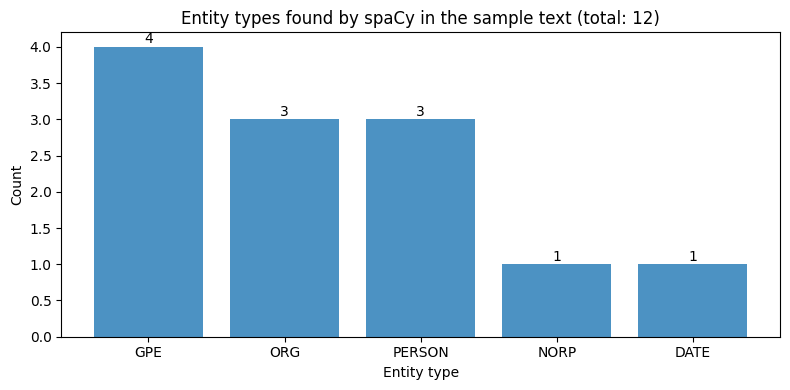

Analysis (computed from the extraction above):
  - 12 entities across 5 types
  - most frequent type: GPE (Countries, cities, states) with 4 mentions
  - GPE: ['Cupertino', 'California', 'Redmond', 'Washington']
  - ORG: ['Apple Inc.', 'Apple', 'Microsoft Corporation']
  - PERSON: ['Tim Cook', 'Steve Jobs', 'Bill Gates']
  - NORP: ['American']
  - DATE: ['1976']


In [4]:
# Visualize the entity-type distribution and summarize what spaCy actually found.
# A bar chart of entity counts shows at a glance what KIND of information this
# text carries — names, organizations, dates — before you read a single sentence.

if HAS_SPACY and nlp is not None:
    import matplotlib.pyplot as plt

    # Count how many entities of each type were extracted above.
    label_counts = Counter(ent["Label"] for ent in entities)
    labels_sorted = sorted(label_counts, key=label_counts.get, reverse=True)
    counts = [label_counts[l] for l in labels_sorted]

    # Bar chart: one bar per entity type; the tallest bar is the text's dominant entity kind.
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(labels_sorted, counts, color="tab:blue", alpha=0.8)
    ax.set_xlabel("Entity type")
    ax.set_ylabel("Count")
    ax.set_title(f"Entity types found by spaCy in the sample text (total: {len(entities)})")
    for i, c in enumerate(counts):
        ax.text(i, c + 0.05, str(c), ha="center")
    plt.tight_layout()
    plt.show()

    # Compute the headline numbers from the actual extraction (nothing hard-coded).
    most_common_label, most_common_n = label_counts.most_common(1)[0]
    print(f"Analysis (computed from the extraction above):")
    print(f"  - {len(entities)} entities across {len(label_counts)} types")
    print(f"  - most frequent type: {most_common_label} "
          f"({spacy.explain(most_common_label)}) with {most_common_n} mentions")
    per_type = {}
    for ent in entities:
        per_type.setdefault(ent["Label"], []).append(ent["Text"])
    for label in labels_sorted:
        print(f"  - {label}: {per_type[label]}")
else:
    print("Note: Install spaCy and download en_core_web_sm to run the visualization")

## Summary

### Key Concepts:
1. **Named Entity Recognition (NER)**: Identifies and classifies entities
   - Common types: PERSON, ORGANIZATION, GPE (location), DATE, MONEY, etc.
   - Useful for information extraction, question answering, knowledge graphs

2. **Part-of-Speech (POS) Tagging**: Assigns grammatical tags to words
   - Common tags: NOUN, VERB, ADJ, ADV, PRON, DET, etc.
   - Useful for parsing, text understanding, feature engineering

3. **spaCy**: Modern NLP library with pre-trained models
   - Fast and efficient
   - Built-in NER and POS tagging
   - Supports multiple languages

### What you did in this notebook
- Extracted named entities from a sample text with the real `en_core_web_sm` model (Part 1)
- POS-tagged a sentence and counted tag frequencies (Part 2)
- Analyzed and visualized the entity-type distribution (Part 3)

### Applications:
- **NER**: Information extraction, knowledge graph construction, search
- **POS Tagging**: Text preprocessing, feature engineering, parsing

**Reference:** Course 07, Unit 3: "Machine Learning for NLP" - NER and POS tagging practical content


## 📚 References

Where these ideas come from — seminal papers first, then a modern survey:

1. Lafferty, J., McCallum, A., & Pereira, F. (2001). *Conditional Random Fields: Probabilistic Models for Segmenting and Labeling Sequence Data*. ICML 2001.
2. Lample, G., Ballesteros, M., Subramanian, S., Kawakami, K., & Dyer, C. (2016). *Neural Architectures for Named Entity Recognition*. NAACL 2016. [arXiv:1603.01360](https://arxiv.org/abs/1603.01360)
3. Li, J., Sun, A., Han, J., & Li, C. (2020). *A Survey on Deep Learning for Named Entity Recognition*. IEEE Transactions on Knowledge and Data Engineering. [arXiv:1812.09449](https://arxiv.org/abs/1812.09449)
4. Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed. draft) — chapter on sequence labeling for part-of-speech and named entities. <https://web.stanford.edu/~jurafsky/slp3/>
